In [1]:
import numpy as np
from qiskit.circuit.library import SwapGate, CXGate, iSwapGate
from qiskit.quantum_info.random import random_unitary
from qiskit.quantum_info import Operator, average_gate_fidelity

from gulps import GulpsDecomposer, GateInvariants
from gulps.core.isa import ContinuousISA
from gulps.config import GulpsConfig

In [2]:
# SWAP gate Weyl coordinates — the maximally degenerate point
swap_inv = GateInvariants.from_unitary(SwapGate(), name="SWAP")
print("SWAP monodromy:", swap_inv.monodromy)
print("SWAP weyl:", swap_inv.weyl)
# (0.5, 0.5, 0.5) = c1=c2=c3, triple degeneracy

SWAP monodromy: [0.25 0.25 0.25]
SWAP weyl: [0.5 0.5 0.5]


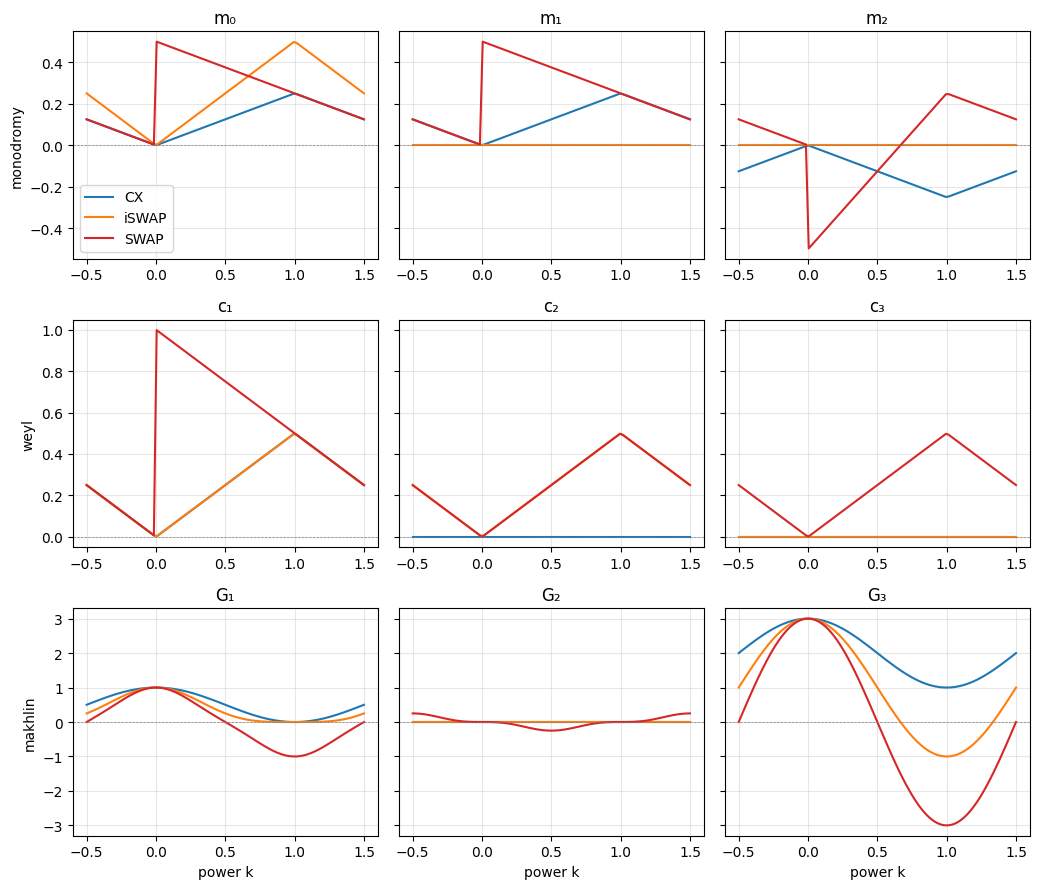

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(10.5, 9), sharey="row")
powers = np.linspace(-0.5, 1.5, 100)

gates = [
    ("CX", CXGate(), "tab:blue"),
    ("iSWAP", iSwapGate(), "tab:orange"),
    ("SWAP", SwapGate(), "tab:red"),
]

# Collect all invariants once
data = {}
for gate_name, gate, color in gates:
    invs = [GateInvariants.from_unitary(gate.power(p)) for p in powers]
    data[gate_name] = {
        "mono": np.array([inv.monodromy for inv in invs]),
        "weyl": np.array([inv.weyl for inv in invs]),
        "makh": np.array([inv.makhlin for inv in invs]),
        "color": color,
    }

row_labels = [
    (["m₀", "m₁", "m₂"], "mono", "monodromy"),
    (["c₁", "c₂", "c₃"], "weyl", "weyl"),
    (["G₁", "G₂", "G₃"], "makh", "makhlin"),
]

for row, (labels, key, ylabel) in enumerate(row_labels):
    for col, label in enumerate(labels):
        ax = axes[row, col]
        for gate_name, _, _ in gates:
            d = data[gate_name]
            ax.plot(powers, d[key][:, col], label=gate_name, color=d["color"])
        ax.set_title(label)
        ax.axhline(0, color="gray", lw=0.5, ls="--")
        ax.grid(True, alpha=0.3)
        if row == 2:
            ax.set_xlabel("power k")
    axes[row, 0].set_ylabel(ylabel)

axes[0, 0].legend()
plt.tight_layout()
plt.show()

In [4]:
print(GateInvariants.from_unitary(SwapGate().power(1.0)).monodromy)
print(GateInvariants.from_unitary(SwapGate()).monodromy)

[0.25 0.25 0.25]
[0.25 0.25 0.25]


In [5]:
GateInvariants.from_unitary(SwapGate().power(0.5)).weyl

array([0.75, 0.25, 0.25])

## Root cause: LP assumes linear-through-origin monodromy

The CPLEX LP parameterizes gate monodromy as `g_i = k * base.monodromy`,
assuming `monodromy(gate^k) = k * monodromy(gate)`. This is true when
gate^k traces a straight line from identity (0,0,0) through the Weyl chamber.

**CX/iSWAP**: `power(k)` gives Weyl (k/2, 0, 0) and (k/2, k/2, 0) respectively → through origin ✓

**SWAP**: `power(k)` gives Weyl (1-k/2, k/2, k/2) → along the TOP FACE (c1+c2=1) ✗

The LP finds intermediates valid under the wrong monodromy, then the solver
gets gates with completely different monodromy → catastrophic failure (residual ~0.3).

In [6]:
# Demonstrate the mismatch: actual SWAP^k monodromy vs LP assumption
swap_inv = GateInvariants.from_unitary(SwapGate())
print(f"{'k':>5s}  {'actual weyl':>30s}  {'LP assumed weyl':>30s}  {'error':>8s}")
print("-" * 80)
for k in [0.1, 0.25, 0.5, 0.75, 1.0]:
    actual = GateInvariants.from_unitary(SwapGate().power(k))
    lp_mono = k * np.array(swap_inv.monodromy)
    lp_weyl = np.array(
        [lp_mono[0] + lp_mono[1], lp_mono[0] + lp_mono[2], lp_mono[1] + lp_mono[2]]
    )
    aw = actual.weyl
    err = np.linalg.norm(aw - lp_weyl)
    print(
        f"k={k:.2f}  ({aw[0]:.4f}, {aw[1]:.4f}, {aw[2]:.4f})  "
        f"({lp_weyl[0]:.4f}, {lp_weyl[1]:.4f}, {lp_weyl[2]:.4f})  "
        f"{'OK' if err < 0.01 else f'{err:.4f}'}"
    )

    k                     actual weyl                 LP assumed weyl     error
--------------------------------------------------------------------------------
k=0.10  (0.9500, 0.0500, 0.0500)  (0.0500, 0.0500, 0.0500)  0.9000
k=0.25  (0.8750, 0.1250, 0.1250)  (0.1250, 0.1250, 0.1250)  0.7500
k=0.50  (0.7500, 0.2500, 0.2500)  (0.2500, 0.2500, 0.2500)  0.5000
k=0.75  (0.6250, 0.3750, 0.3750)  (0.3750, 0.3750, 0.3750)  0.2500
k=1.00  (0.5000, 0.5000, 0.5000)  (0.5000, 0.5000, 0.5000)  OK


## Fix: affine monodromy parameterization

The actual monodromy is perfectly affine in k (fit error ~1e-16):
`m(k) = A + S*k` where A = monodromy intercept, S = slope.

For CX/iSWAP: A ≈ (0,0,0), reduces to current `g_i = B*k_i`.
For SWAP: A = (0.5, 0.5, -0.5), corrects for the wrapping path.

LP constraint: `g_i = A*y_i + S*k_i` (A activates only when gate is on).

In [7]:
# Affine parameters for common gates
for name, gate in [("CX", CXGate()), ("iSWAP", iSwapGate()), ("SWAP", SwapGate())]:
    inv = GateInvariants.from_unitary(gate)
    m_full = np.array(inv.monodromy)
    m_half = np.array(GateInvariants.from_unitary(gate.power(0.5)).monodromy)
    S = 2.0 * (m_full - m_half)
    A = m_full - S
    print(
        f"{name:>6s}: A=({A[0]:+.4f},{A[1]:+.4f},{A[2]:+.4f})  "
        f"S=({S[0]:+.4f},{S[1]:+.4f},{S[2]:+.4f})  "
        f"||A||={np.linalg.norm(A):.2e}"
    )

    CX: A=(+0.0000,+0.0000,-0.0000)  S=(+0.2500,+0.2500,-0.2500)  ||A||=1.44e-16
 iSWAP: A=(+0.0000,+0.0000,+0.0000)  S=(+0.5000,+0.0000,+0.0000)  ||A||=0.00e+00
  SWAP: A=(+0.5000,+0.5000,-0.5000)  S=(-0.2500,-0.2500,+0.7500)  ||A||=8.66e-01


## Verification: SWAP now works, CX/iSWAP unregressed

In [8]:
# Test all three gate families with the affine LP fix
config = GulpsConfig(flag_duration=0)

for name, gate in [("eSWAP", SwapGate()), ("eCX", CXGate()), ("eiSWAP", iSwapGate())]:
    isa = ContinuousISA.from_base_gate(gate, name=name)
    dec = GulpsDecomposer(isa=isa, config_options=config)
    fids = []
    for seed in range(20):
        U = random_unitary(4, seed=seed).data
        circ = dec(U)
        fids.append(average_gate_fidelity(Operator(U), Operator(circ)))
    print(
        f"{name:>7s}: min_fid={min(fids):.6e}  "
        f"all_pass={all(f > 0.999 for f in fids)}  "
        f"({sum(f > 0.999 for f in fids)}/20)"
    )

  eSWAP: min_fid=1.000000e+00  all_pass=True  (20/20)
    eCX: min_fid=1.000000e+00  all_pass=True  (20/20)
 eiSWAP: min_fid=1.000000e+00  all_pass=True  (20/20)
